In [1]:
# After learning the Datacamp course from TG, here are some viable model architectures I believe will work for our seq_2_seq model

In [2]:
import tensorflow as tf

2025-07-08 17:20:20.521205: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-08 17:20:20.557015: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-08 17:20:20.557040: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-08 17:20:20.557969: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-08 17:20:20.563855: I tensorflow/core/platform/cpu_feature_guar

In [3]:
inp_layer = tf.keras.layers.Input(shape = (13, 32))

lstm_layer = tf.keras.layers.LSTM(64, return_state = True, activation = 'relu')

lstm_out, lstm_state, lstm_c = lstm_layer(inp_layer)

2025-07-08 17:20:22.311821: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:86:00.0, compute capability: 7.0


In [4]:
encoder_model = tf.keras.models.Model(inputs = inp_layer, outputs = lstm_state)

In [5]:
encoder_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 13, 32)]          0         
                                                                 
 lstm (LSTM)                 [(None, 64),              24832     
                              (None, 64),                        
                              (None, 64)]                        
                                                                 
Total params: 24832 (97.00 KB)
Trainable params: 24832 (97.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [6]:
lstm_out.shape

TensorShape([None, 64])

In [7]:
# repeat the final context vector for the output time stpe number - which is 7
rep_layer = tf.keras.layers.RepeatVector(7)(lstm_out)

In [8]:
lstm_dec_layer = tf.keras.layers.LSTM(64, return_sequences = True, activation = 'relu')

In [9]:
decoder_out1 = lstm_dec_layer(rep_layer, initial_state=[lstm_state, lstm_c])

In [10]:
# define another LSTM? with 32 hidden?
lstm_dec_layer2 = tf.keras.layers.LSTM(32, return_sequences = True, activation = 'relu')

In [11]:
decoder_out2 = lstm_dec_layer2(decoder_out1)

In [12]:
decoder_out2.shape

TensorShape([None, 7, 32])

In [13]:
# see that we have the needed shape- so no need of a dense layer

In [14]:
proposed_seq2seq_0 = tf.keras.models.Model(inputs = inp_layer, outputs = decoder_out2)

In [15]:
proposed_seq2seq_0.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 13, 32)]             0         []                            
                                                                                                  
 lstm (LSTM)                 [(None, 64),                 24832     ['input_1[0][0]']             
                              (None, 64),                                                         
                              (None, 64)]                                                         
                                                                                                  
 repeat_vector (RepeatVecto  (None, 7, 64)                0         ['lstm[0][0]']                
 r)                                                                                         

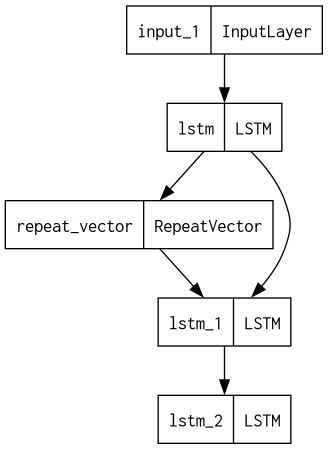

In [16]:
tf.keras.utils.plot_model(proposed_seq2seq_0)

In [17]:
# maybe this is a better model as we do not use a dense layer? - might want to explore this?